# Information Presentation & Data Visualisation

## 04 Lab Exercise sheet: Colour

This lab is designed to practise key colour concepts in data visualisation, including tasks for exploring perceptual and cognitive aspects of colour, colour encoding, and colour palettes. Feel free to interact with and even experiment with the colour materials found in the class.

## Task 1: Load and clean data, and compute centroids

a) Load the synthetic_cars dataset, b) inspect data c) correct any mispellings, and d) compute the centroid of the RGB coordinates for each car.

In [99]:
import pandas as pd

# a) Load the synthetic_cars dataset
data_cars = pd.read_csv("synthetic_cars.csv")
print("Initial DataFrame:")
print(data_cars.head(), "\n")

Initial DataFrame:
         Car    R    G    B
0      Tesal  130  147    0
1   Merecdes   15  255  255
2  Chevroelt  249  244    9
3     Nissan   11  121  109
4    Huyndai  128  130  123 



In [103]:
# b) Inspect data
print("Data info:")
print(data_cars.info(), "\n")
print("Missing values:")
print(data_cars.isnull().sum(), "\n")
print("Unique car names before correction:")
print(data_cars['Car'].unique(), "\n")


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Car     100 non-null    object
 1   R       100 non-null    int64 
 2   G       100 non-null    int64 
 3   B       100 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 3.3+ KB
None 

Missing values:
Car    0
R      0
G      0
B      0
dtype: int64 

Unique car names before correction:
['Tesal' 'Merecdes' 'Chevroelt' 'Nissan' 'Huyndai' 'BMW' 'Toyoat' 'oFrd'
 'eMrcedes' 'Nisasn' 'hCevrolet' 'uAdi' 'oTyota' 'Tyoota' 'Hyundia' 'Hodna'
 'iNssan' 'Hnoda' 'Mercedse' 'Adui' 'Mercdees' 'Mrecedes' 'Nissna'
 'yHundai' 'Chevrloet' 'Chervolet' 'Tooyta' 'Chverolet' 'Cehvrolet'
 'Hynudai' 'oHnda' 'Auid' 'Tsela' 'eTsla' 'Frod' 'Hyunadi' 'Honad'] 



In [105]:
# c) Correct any misspellings by mapping the names of the car brands
car_name_corrections = {
    'Tesal': 'Tesla', 'Tsela': 'Tesla', 'eTsla': 'Tesla',
    'Merecdes': 'Mercedes', 'eMrcedes': 'Mercedes', 'Mercedse': 'Mercedes', 
    'Mercdees': 'Mercedes', 'Mrecedes': 'Mercedes',
    'Chevroelt': 'Chevrolet', 'hCevrolet': 'Chevrolet', 'Chevrloet': 'Chevrolet', 
    'Chervolet': 'Chevrolet', 'Chverolet': 'Chevrolet', 'Cehvrolet': 'Chevrolet',
    'Nissan': 'Nissan', 'Nisasn': 'Nissan', 'iNssan': 'Nissan', 'Nissna': 'Nissan',
    'Hyundai': 'Hyundai', 'Huyndai': 'Hyundai', 'Hyundia': 'Hyundai', 
    'yHundai': 'Hyundai', 'Hynudai': 'Hyundai', 'Hyunadi': 'Hyundai',
    'Honda': 'Honda', 'Hodna': 'Honda', 'Honad': 'Honda', 'oHnda': 'Honda', 'Hnoda': 'Honda',
    'Toyota': 'Toyota', 'Toyoat': 'Toyota', 'oTyota': 'Toyota', 'Tyoota': 'Toyota', 'Tooyta': 'Toyota',
    'Audi': 'Audi', 'uAdi': 'Audi', 'Auid': 'Audi', 'Adui': 'Audi',
    'Ford': 'Ford', 'Frod': 'Ford', 'oFrd': 'Ford',
    'BMW': 'BMW'
}

# Apply the corrections
data_cars['Car'] = data_cars['Car'].replace(car_name_corrections)

# Check unique values after correction
print("Unique car names after correction:")
print(data_cars['Car'].unique(), "\n")

Unique car names after correction:
['Tesla' 'Mercedes' 'Chevrolet' 'Nissan' 'Hyundai' 'BMW' 'Toyota' 'Ford'
 'Audi' 'Honda'] 

RGB centroids per car brand:
         Car  centroid_R  centroid_G  centroid_B
0       Audi  128.533333    5.200000  132.666667
1        BMW  254.250000    3.500000  244.750000
2  Chevrolet  252.411765  249.176471    2.647059
3       Ford    0.857143    5.000000  252.000000
4      Honda    5.692308  251.692308    4.307692
5    Hyundai  125.111111  125.888889  128.777778
6   Mercedes    5.625000  253.375000  247.000000
7     Nissan    6.625000  128.375000  128.000000
8      Tesla  124.777778  125.000000    5.444444
9     Toyota  251.100000    4.400000    5.600000


In [107]:
# d) Compute RGB centroid per car brand
centroids = data_cars.groupby('Car')[['R', 'G', 'B']].mean().reset_index()
centroids.rename(columns={'R': 'centroid_R', 'G': 'centroid_G', 'B': 'centroid_B'}, inplace=True)

# Display the centroids
print("RGB centroids per car brand:")
print(centroids)


RGB centroids per car brand:
         Car  centroid_R  centroid_G  centroid_B
0       Audi  128.533333    5.200000  132.666667
1        BMW  254.250000    3.500000  244.750000
2  Chevrolet  252.411765  249.176471    2.647059
3       Ford    0.857143    5.000000  252.000000
4      Honda    5.692308  251.692308    4.307692
5    Hyundai  125.111111  125.888889  128.777778
6   Mercedes    5.625000  253.375000  247.000000
7     Nissan    6.625000  128.375000  128.000000
8      Tesla  124.777778  125.000000    5.444444
9     Toyota  251.100000    4.400000    5.600000


## Task 2: Colour maps in data visualisation

Design versions of a pie chart showing the number of cars using sequential, categorical, and diverging colour maps.

In [148]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Count number of entries per car
car_counts = data_cars['Car'].value_counts()
car_counts

Car
Chevrolet    17
Audi         15
Honda        13
Toyota       10
Tesla         9
Hyundai       9
Mercedes      8
Nissan        8
Ford          7
BMW           4
Name: count, dtype: int64

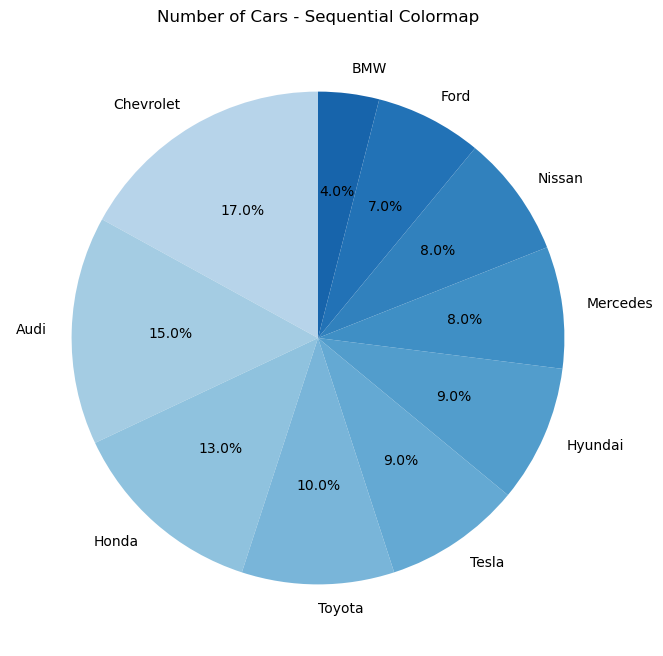

In [140]:
# 1. Pie chart with sequential colormap. Sequential colormaps are good for ordered data (e.g., lighter → darker)
colors_seq = cm.Blues(np.linspace(0.3, 0.8, len(car_counts)))
plt.figure(figsize=(8,8))
plt.pie(car_counts, labels=car_counts.index, autopct='%1.1f%%', colors=colors_seq, startangle=90)
plt.title("Number of Cars - Sequential Colormap")
plt.show()

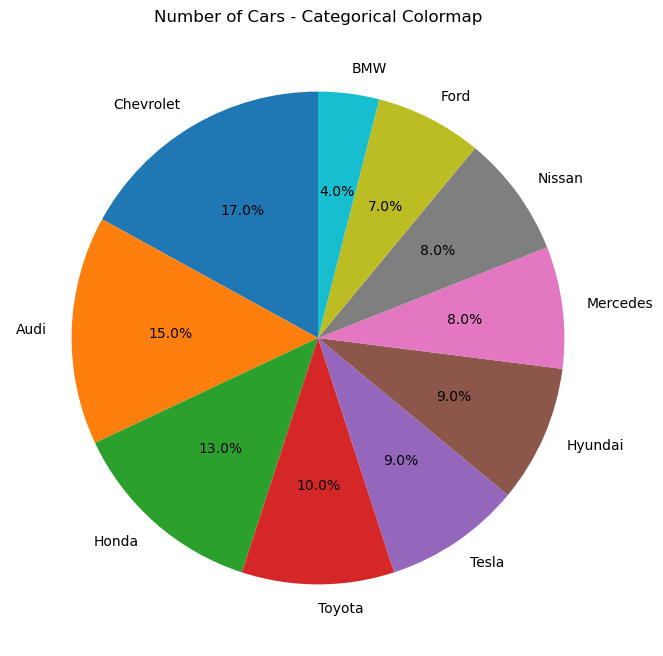

In [134]:
# 3. Pie chart with categorical colormap. Categorical colormaps are ideal for distinct categories
colors_cat = cm.tab10.colors[:len(car_counts)]  # first n colors from tab10
plt.figure(figsize=(8, 8))
plt.pie(car_counts, labels=car_counts.index, autopct='%1.1f%%', colors=colors_cat, startangle=90)
plt.title("Number of Cars - Categorical Colormap")
plt.show()

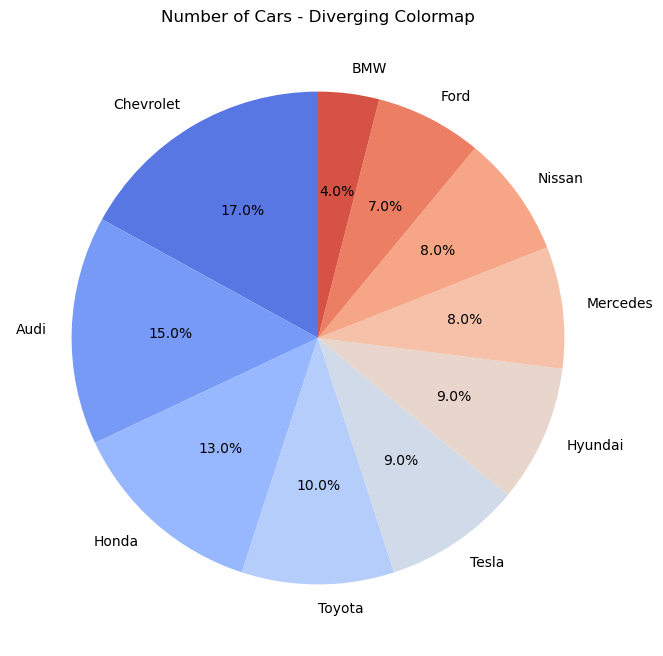

In [128]:
# 3. Pie chart with diverging colormap. Diverging colormaps highlight differences from a midpoint
colors_div = cm.coolwarm(np.linspace(0.1, 0.9, len(car_counts)))
plt.figure(figsize=(8, 8))
plt.pie(car_counts, labels=car_counts.index, autopct='%1.1f%%', colors=colors_div, startangle=90)
plt.title("Number of Cars - Diverging Colormap")
plt.show()

## Task 3: Create a perceptually uniform colour gradient  

Create a gradient of n steps between the centroids of yellow and blue in CIELAB and plot after converting to RGB via CIEXYZ

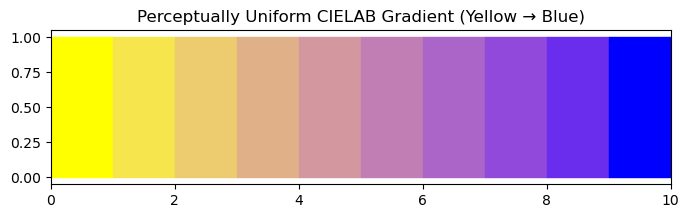

In [142]:
import colour
import numpy as np

# Define RGB colours as float arrays (0-1 range)
yellow_rgb = np.array([255, 255, 0], dtype=float) / 255
blue_rgb   = np.array([0, 0, 255], dtype=float) / 255

# Convert RGB → CIEXYZ → CIELAB
# RGB to XYZ
yellow_xyz = colour.sRGB_to_XYZ(yellow_rgb)
blue_xyz   = colour.sRGB_to_XYZ(blue_rgb)

# XYZ to Lab (D65 illuminant)
yellow_lab = colour.XYZ_to_Lab(yellow_xyz)
blue_lab   = colour.XYZ_to_Lab(blue_xyz)


# Interpolate in CIELAB space
n = 10  # number of gradient steps

# Linear interpolation in Lab
gradient_lab = np.linspace(yellow_lab, blue_lab, n)


# Convert CIELAB → CIEXYZ → RGB
# Lab → XYZ → sRGB
gradient_rgb = np.array([colour.Lab_to_XYZ(lab) for lab in gradient_lab])
gradient_rgb = np.array([colour.XYZ_to_sRGB(xyz) for xyz in gradient_rgb])

# Clip RGB to valid range [0,1]
gradient_rgb = np.clip(gradient_rgb, 0, 1)


# Plot the gradient
plt.figure(figsize=(8, 2))

for i, color in enumerate(gradient_rgb):
    plt.fill_between([i, i+1], 0, 1, color=color)

plt.xlim(0, n)
plt.title("Perceptually Uniform CIELAB Gradient (Yellow → Blue)")
plt.show()

## Task 4: Colour vision variance in data visualisation

Save the categorical version of your pie chart as an image. b) Upload it to a colour blindness simulator (https://www.color-blindness.com/coblis-color-blindness-simulator/), simulate how your chart would be seen by people with different colour vision deficiencies, and write a paragraph with your observations for two of them.

In [144]:
# Count number of entries per car
car_counts = data_cars['Car'].value_counts()

# Create categorical pie chart
plt.figure(figsize=(8, 8))
colors = plt.cm.tab20(np.arange(len(car_counts)))  # categorical
plt.pie(car_counts, labels=car_counts.index, autopct='%1.1f%%', colors=colors)
plt.title("Number of Cars per Brand (Categorical Color Map)")

# Save image
plt.savefig("categorical_car_pie_chart.png", dpi=300, bbox_inches='tight')
plt.close()

### Worksheets should be submitted on Canvas by the Monday after the lab at 23:59.